<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/time_series_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, header=0,index_col=0, parse_dates=True)
df.columns = ['passengers']

In [4]:
result = seasonal_decompose(df['passengers'], model='multiplicative',period=12)

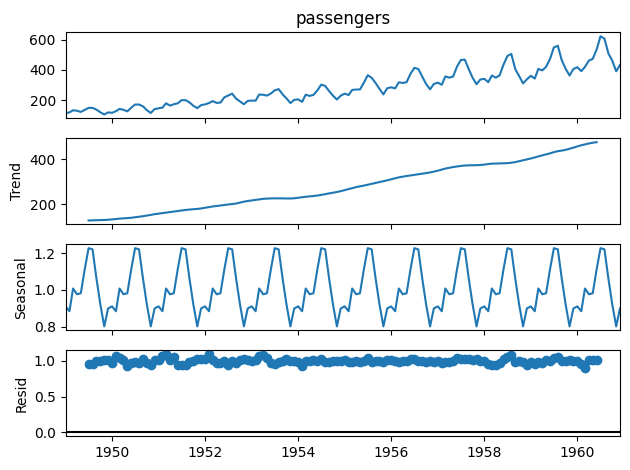

In [5]:
result.plot()
plt.tight_layout()
plt.show()

In [6]:
df.head()

,passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [7]:
df['diff1'] = df['passengers'].diff()

In [8]:
df = df.dropna()

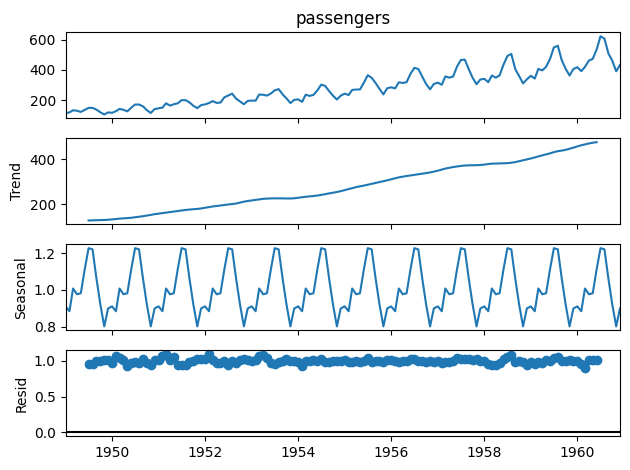

In [9]:
result.plot()
plt.tight_layout()
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

In [11]:
result = adfuller(df['passengers'])
print(f"Raw p-value: {result[1]:.4f}")

Raw p-value: 0.9915


In [12]:
#first difference removes trend
result2 = adfuller(df['diff1'].dropna())
print(f"After diff(1) p-value: {result2[1]:.4f}")

After diff(1) p-value: 0.0542


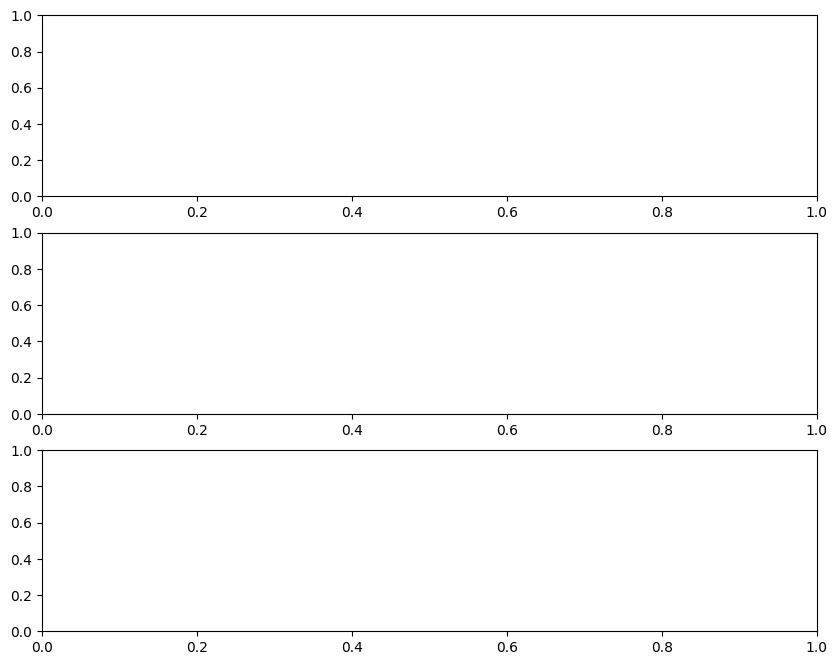

In [13]:
#plot all three to see what changed
fig, axes = plt.subplots(3,1, figsize=(10,8))

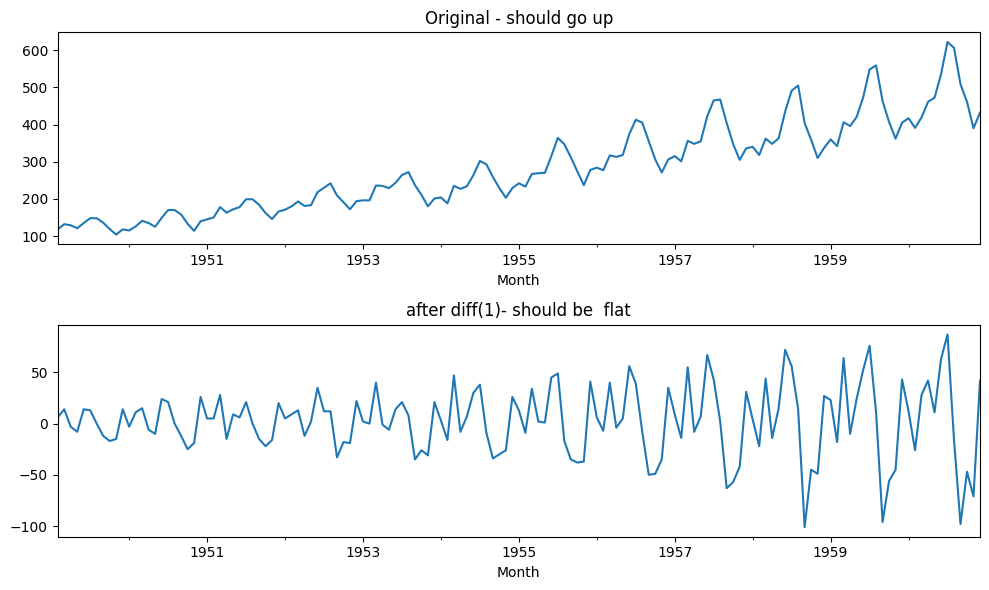

In [14]:
fig, axes = plt.subplots(2,1, figsize=(10,6))

#original - should look like it's going up
df['passengers'].plot(ax=axes[0],title='Original - should go up')

#after diif1 - should look flat around zero
df['diff1'].plot(ax=axes[1],title='after diff(1)- should be  flat')

plt.tight_layout()
plt.show()

In [15]:
df.head()


,passengers,diff1
Month,,
1949-02-01,118,6.0
1949-03-01,132,14.0
1949-04-01,129,-3.0
1949-05-01,121,-8.0
1949-06-01,135,14.0


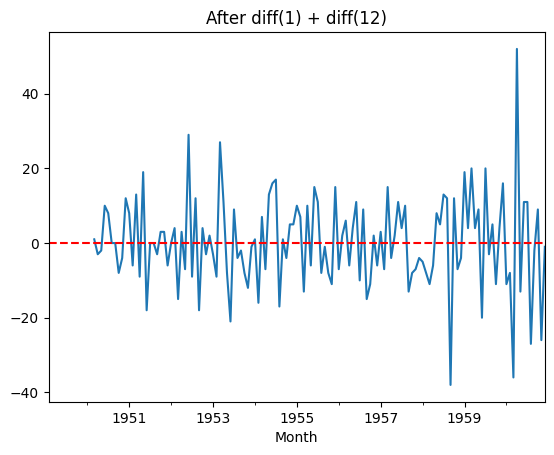

In [16]:
# Remove trend and seasonality together
df['diff_both'] = df['passengers'].diff(1).diff(12)

#plot
df['diff_both'].plot(title='After diff(1) + diff(12)')
plt.axhline(y=0,color='red',linestyle='--') # zero line for reference
plt.show()

In [18]:
df['day_wise'] = df['passengers'].diff(24)

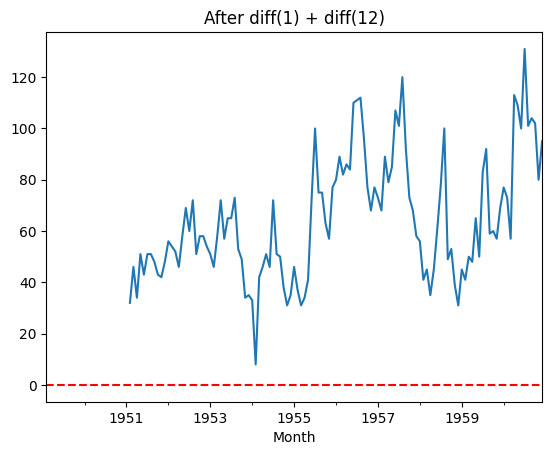

In [19]:
df['day_wise'].plot(title='After diff(1) + diff(12)')
plt.axhline(y=0,color='red',linestyle='--') # zero line for reference
plt.show()